# Structured CSV Batch Fitting

This notebook shows how to fit many SWV traces from a structured dataframe or CSV file. The preferred input shape is one row per voltammogram: `voltage` is the full array of potentials, `current` is the full array of currents, and the remaining columns are metadata such as frequency, sample number, channel, and time.

The batch API fits each row and returns JSON/CSV-friendly results that can be plotted or opened in the Streamlit viewer.


In [4]:
from pathlib import Path
import sys
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / "src" / "aswift").exists():
        repo_root = candidate
        break
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from aswift import (
    fit_dataframe,
    formatted_csvs_to_dataframe,
    long_form_to_trace_dataframe,
    plot_fit_result_from_row,
    plot_signal_over_time,
)


## Required Structured DataFrame Shape

Each row should represent one complete voltammogram.

Required array columns:

- `voltage`: full one-dimensional array/list of potentials for the trace.
- `current`: full one-dimensional array/list of measured currents for the trace.

Recommended metadata columns:

- `file`: source file or trace name.
- `hz`: SWV frequency.
- `num`: sample/acquisition number, usually the time-ordered replicate index.
- `channel`: electrode/channel identifier.
- `time`: elapsed acquisition time, usually hours from the first measurement.

`fit_dataframe` treats each row as one trace when `voltage` and `current` contain arrays. The metadata columns are carried through to the results dataframe so users can sort, filter, group, and plot later. Older long-form tables with one row per sampled point are still supported for compatibility, but the array-per-trace format is the cleaner format for new data.


In [5]:
STRUCTURED_DATA_URL = None  # e.g. "https://.../aswift_trace_table_demo.csv"
STRUCTURED_PATH = Path("data/aswift_trace_table_demo.csv")

if STRUCTURED_DATA_URL and not STRUCTURED_PATH.exists():
    STRUCTURED_PATH.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(str(STRUCTURED_DATA_URL), STRUCTURED_PATH)

if STRUCTURED_PATH.exists():
    df = pd.read_csv(STRUCTURED_PATH)

else:
    rng = np.random.default_rng(4)
    volts = np.linspace(-0.4, 0.0, 400)
    rows = []
    for hz in (150, 250):
        for channel in range(2):
            for num in range(15):
                amp = 0.35 + 0.03 * num + 0.04 * channel
                center = -0.18 + 0.015 * channel
                background = 1.0 + 0.08 * volts - 0.1 * num * volts
                peak = amp * np.exp(-0.5 * ((volts - center) / 0.02) ** 2)
                noise = rng.normal(0.0, 0.004, size=volts.size)
                current = background + peak + noise
                rows.append({
                    "file": f"{hz}hz-{num + 1}.csv",
                    "hz": hz,
                    "num": num,
                    "channel": channel,
                    "time": num * 0.25,
                    "voltage": volts.tolist(),
                    "current": current.tolist(),
                })
    df = pd.DataFrame(rows)

df.head()


,file,hz,num,channel,time,voltage,current
0,150hz-1.csv,150,0,0,0.00,"[-0.4, -0.39899749373433585, -0.39799498746867...","[0.9653928353895532, 0.96738133133195, 0.97481..."
1,150hz-2.csv,150,1,0,0.25,"[-0.4, -0.39899749373433585, -0.39799498746867...","[0.998009486850557, 1.0035208104830142, 1.0141..."
2,150hz-3.csv,150,2,0,0.50,"[-0.4, -0.39899749373433585, -0.39799498746867...","[1.0519253757056428, 1.0471747822678217, 1.044..."
3,150hz-4.csv,150,3,0,0.75,"[-0.4, -0.39899749373433585, -0.39799498746867...","[1.0820958564884415, 1.0895376777635135, 1.091..."
4,150hz-5.csv,150,4,0,1.00,"[-0.4, -0.39899749373433585, -0.39799498746867...","[1.1297780668620803, 1.1263761938753332, 1.125..."


In [6]:
results = fit_dataframe(
    df,
    method="aswift",    # or "poly_linear"
    n_workers=1,
)

results[["hz", "num", "channel", "peak", "peak_voltage", "success"]].head()


,hz,num,channel,peak,peak_voltage,success
0,150,0,0,0.353676,-0.180451,True
1,150,1,0,0.381420,-0.179449,True
2,150,2,0,0.411659,-0.180451,True
3,150,3,0,0.440624,-0.180451,True
4,150,4,0,0.471580,-0.180451,True


## Optional Streamlit Viewer

Save the structured batch results and launch the lightweight Streamlit viewer with the JSON preloaded. The printed link opens directly on these results and the app sorts and filters by channel, frequency, and sample order.

In [7]:
OUTPUT_DIR = Path("outputs/structured_csv_demo")
RESULTS_JSON = OUTPUT_DIR / "structured_fit_results.json"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
results.to_json(RESULTS_JSON, orient="records", indent=2)

import socket
import subprocess
import time


def available_port(preferred=8501):
    for p in (preferred, 0):
        with socket.socket() as sock:
            try:
                sock.bind(("localhost", p))
            except OSError:
                continue
            return sock.getsockname()[1]
    raise RuntimeError("Could not find an available Streamlit port.")


import aswift.analysis.structured_results_viewer as aswift_viewer

viewer_script = Path(str(aswift_viewer.__file__)).resolve()
results_json = RESULTS_JSON.resolve()
port = available_port()
viewer_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "--server.headless=true",
        f"--server.port={port}",
        str(viewer_script),
        "--",
        str(results_json),
    ],
    cwd=repo_root,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.STDOUT,
)
time.sleep(1)
if viewer_process.poll() is not None:
    raise RuntimeError("Streamlit failed to start. Confirm streamlit is installed in this notebook kernel.")
print(f"Saved results to {results_json}")
print(f"Streamlit viewer running at http://localhost:{port} with results loaded")
print(f"Streamlit process id: {viewer_process.pid}")

Saved results to /Users/Max_1/PycharmProjects/aswift/examples/outputs/structured_csv_demo/structured_fit_results.json
Streamlit viewer running at http://localhost:8501 with results loaded
Streamlit process id: 9663


## Stop The Streamlit Viewer

Run this cell when you are done with the browser tab to stop the background Streamlit process started above.


In [8]:
if "viewer_process" in globals() and viewer_process.poll() is None:
    viewer_process.terminate()
    try:
        viewer_process.wait(timeout=5)
    except subprocess.TimeoutExpired:
        viewer_process.kill()
        viewer_process.wait(timeout=5)
    print("Streamlit viewer stopped.")
elif "viewer_process" in globals():
    print("Streamlit viewer is already stopped.")
else:
    print("No Streamlit viewer process was started in this notebook session.")


Streamlit viewer stopped.


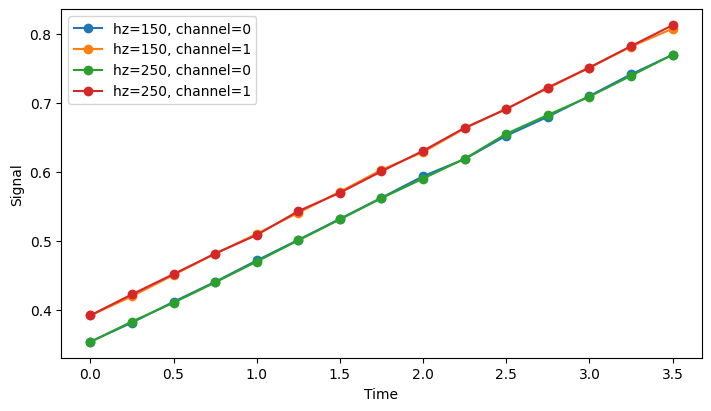

In [9]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
plot_signal_over_time(results, ax=ax)
plt.show()